In [7]:
import pandas as pd

data = {
    'Brand': ['Dell', 'HP', 'Lenovo', 'Apple', 'Asus', 'Acer', 'Dell', 'HP', 'Lenovo', 'Apple',
              'Asus', 'Acer', 'Dell', 'HP', 'Lenovo', 'Apple', 'Asus', 'Acer', 'Dell', 'HP'],
    'RAM_GB': [8, 16, 8, 16, 8, 4, 16, 8, 16, 8, 4, 8, 32, 16, 8, 32, 16, 4, 8, 16],
    'Storage_GB': [256, 512, 512, 512, 256, 128, 1024, 512, 1024, 256, 128, 256, 1024, 512, 256, 1024, 512, 128, 256, 512],
    'Processor_Gen': [10, 11, 10, 12, 10, 8, 12, 11, 12, 11, 8, 9, 13, 12, 10, 13, 11, 8, 10, 12],
    'Screen_Size': [15.6, 14, 15.6, 13.3, 15.6, 14, 15.6, 14, 15.6, 13.3, 14, 15.6, 17, 15.6, 14, 16, 15.6, 14, 15.6, 15.6],
    'Price': [55000, 70000, 65000, 120000, 60000, 40000, 90000, 68000, 85000, 110000,
              45000, 50000, 130000, 85000, 62000, 150000, 78000, 42000, 58000, 88000]
}

df = pd.DataFrame(data)

df.to_csv('laptop_prices.csv', index=False)

df.head()

,Brand,RAM_GB,Storage_GB,Processor_Gen,Screen_Size,Price
0,Dell,8,256,10,15.6,55000
1,HP,16,512,11,14.0,70000
2,Lenovo,8,512,10,15.6,65000
3,Apple,16,512,12,13.3,120000
4,Asus,8,256,10,15.6,60000


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Convert Brand to numbers
df_encoded = pd.get_dummies(df, columns=['Brand'], drop_first=True)

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 2))

Mean Absolute Error: 11515.16
R² Score: 0.9


In [9]:
new_laptop = pd.DataFrame({
    'RAM_GB': [16],
    'Storage_GB': [512],
    'Processor_Gen': [12],
    'Screen_Size': [15.6],
    'Brand_Apple': [0],
    'Brand_Asus': [0],
    'Brand_Dell': [1],
    'Brand_HP': [0],
    'Brand_Lenovo': [0]
})

predicted_price = model.predict(new_laptop)

print("Predicted Laptop Price: NPR", round(predicted_price[0], 2))

Predicted Laptop Price: NPR 83736.47


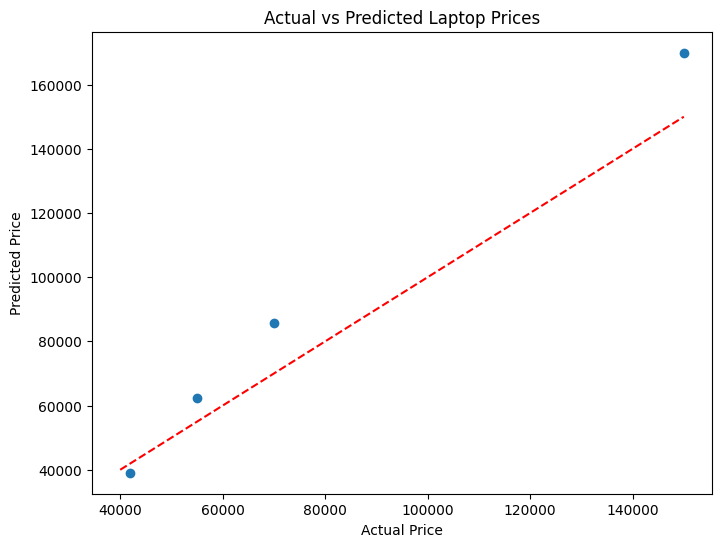

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Laptop Prices")

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

plt.show()